In [2]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json

from reconstruction import IncrementalSfM, compute_intrinsic_matrix
from visualization import save_ply, plot_3d_points
from bundle_adjustment import compute_reprojection_errors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'IncrementalSfM' from 'reconstruction' (C:\Users\altaf\SfM-Interactive-Virtual-Tour\src\reconstruction.py)

In [3]:
image_folder = r"C:\Users\altaf\OneDrive\Desktop\cv pics"

image_files = sorted([f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
image_paths = [os.path.join(image_folder, f) for f in image_files]

print(f"Found {len(image_paths)} images")

images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        images.append(img)
    else:
        print(f"  FAILED: {path}")

print(f"\nTotal images loaded: {len(images)}")

Found 18 images

Total images loaded: 18


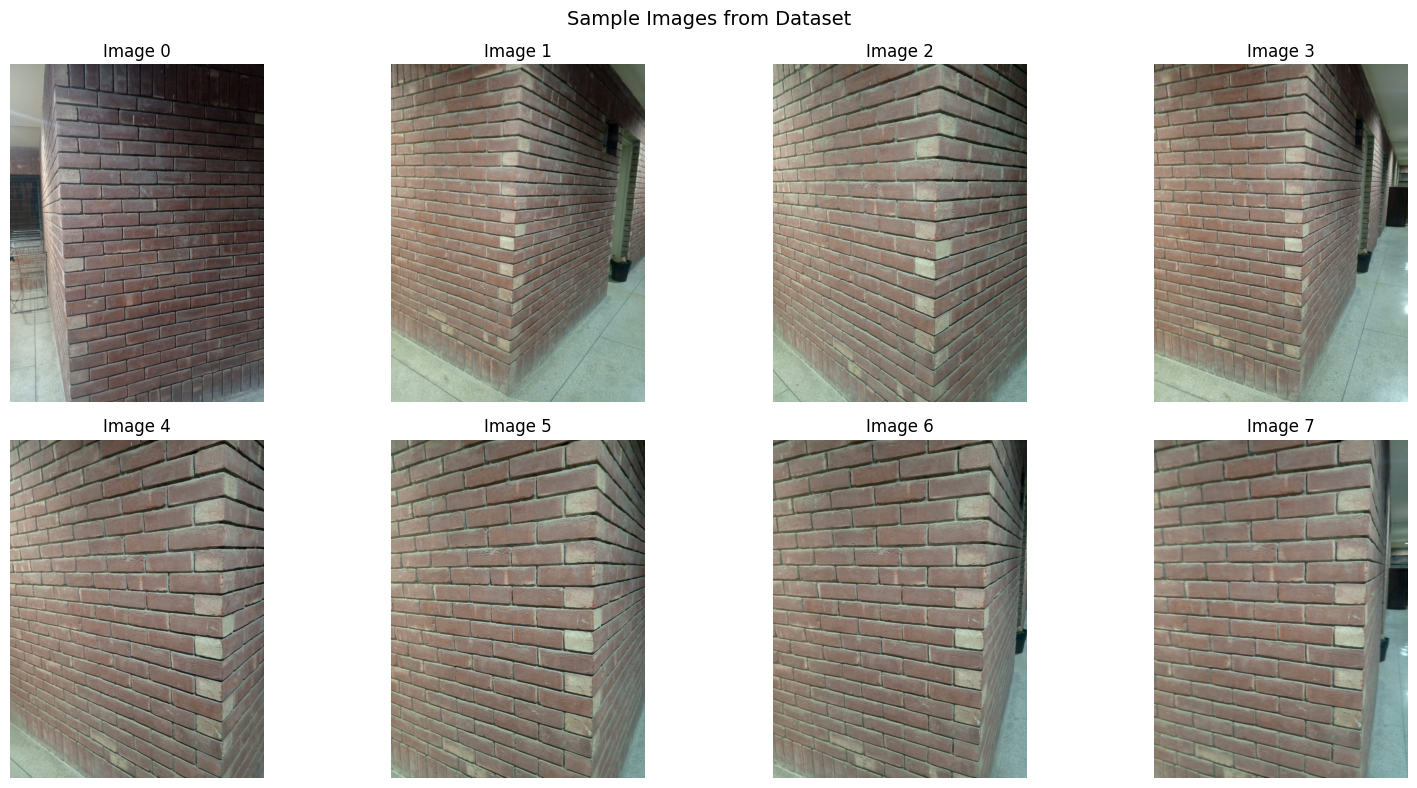

In [4]:
# Display first few images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images):
        ax.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Image {i}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle("Sample Images from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
h, w = images[0].shape[:2]
print(f"Image dimensions: {w} x {h}")

K = compute_intrinsic_matrix(w, h)
print(f"\nIntrinsic Matrix K:")
print(K)

Image dimensions: 960 x 1280


NameError: name 'compute_intrinsic_matrix' is not defined

In [6]:
success = sfm.initialize_from_two_view(images[0], images[1])

if success:
    print(f"\n✓ Two-view initialization successful!")
    print(f"  Initial points: {len(sfm.points_3d)}")
    print(f"  Cameras registered: {len(sfm.camera_poses)}")
else:
    print("✗ Two-view initialization failed!")

NameError: name 'sfm' is not defined

In [7]:
failed_views = []

for i in range(2, len(images)):
    print(f"\n--- Adding Image {i} ---")
    success = sfm.add_view(images[i])
    
    if success:
        print(f"✓ Image {i} added successfully")
    else:
        print(f"✗ Image {i} FAILED to register")
        failed_views.append(i)

print("\n" + "=" * 60)
print("INCREMENTAL SFM SUMMARY")
print("=" * 60)
print(f"Total images: {len(images)}")
print(f"Registered cameras: {len(sfm.camera_poses)}")
print(f"Failed views: {len(failed_views)} - {failed_views if failed_views else 'None'}")
print(f"Total 3D points: {len(sfm.points_3d)}")


--- Adding Image 2 ---


NameError: name 'sfm' is not defined

In [8]:
points_before = sfm.points_3d.copy()
colors_before = sfm.point_colors.copy() if len(sfm.point_colors) > 0 else np.array([])

save_ply("reconstruction_before_BA.ply", points_before, colors_before)
print(f"Saved {len(points_before)} points to reconstruction_before_BA.ply")

NameError: name 'sfm' is not defined

In [9]:
errors_before, mean_error_before = compute_reprojection_errors(
    sfm.points_3d, sfm.observations, sfm.camera_poses, sfm.K, sfm.all_keypoints
)

print("=" * 60)
print("REPROJECTION ERRORS BEFORE REFINEMENT")
print("=" * 60)
print(f"Total observations: {len(errors_before)}")
print(f"Mean error: {mean_error_before:.3f} pixels")

error_values_before = [e[2] for e in errors_before]
if len(error_values_before) > 0:
    print(f"Median error: {np.median(error_values_before):.3f} pixels")
    print(f"Max error: {np.max(error_values_before):.3f} pixels")
    print(f"Points with error < 1px: {np.sum(np.array(error_values_before) < 1)} ({100*np.sum(np.array(error_values_before) < 1)/len(error_values_before):.1f}%)")
    print(f"Points with error < 3px: {np.sum(np.array(error_values_before) < 3)} ({100*np.sum(np.array(error_values_before) < 3)/len(error_values_before):.1f}%)")

NameError: name 'compute_reprojection_errors' is not defined

In [10]:
print("=" * 60)
print("STEP 3: Bundle Adjustment Refinement")
print("=" * 60)

sfm.refine_reconstruction(use_bundle_adjustment=True, num_iterations=3)

STEP 3: Bundle Adjustment Refinement


NameError: name 'sfm' is not defined

In [11]:
errors_after, mean_error_after = compute_reprojection_errors(
    sfm.points_3d, sfm.observations, sfm.camera_poses, sfm.K, sfm.all_keypoints
)

print("=" * 60)
print("REPROJECTION ERRORS AFTER REFINEMENT")
print("=" * 60)
print(f"Total observations: {len(errors_after)}")
print(f"Mean error: {mean_error_after:.3f} pixels")

error_values_after = [e[2] for e in errors_after] if errors_after else [0]
if len(error_values_after) > 0:
    print(f"Median error: {np.median(error_values_after):.3f} pixels")
    print(f"Max error: {np.max(error_values_after):.3f} pixels")
    print(f"Points with error < 1px: {np.sum(np.array(error_values_after) < 1)} ({100*np.sum(np.array(error_values_after) < 1)/len(error_values_after):.1f}%)")
    print(f"Points with error < 3px: {np.sum(np.array(error_values_after) < 3)} ({100*np.sum(np.array(error_values_after) < 3)/len(error_values_after):.1f}%)")

print(f"\n--- Improvement ---")
print(f"Mean error: {mean_error_before:.3f} → {mean_error_after:.3f} pixels")
if mean_error_before > 0:
    print(f"Reduction: {100*(mean_error_before - mean_error_after)/mean_error_before:.1f}%")
print(f"Points: {len(points_before)} → {len(sfm.points_3d)}")

NameError: name 'compute_reprojection_errors' is not defined

NameError: name 'error_values_before' is not defined

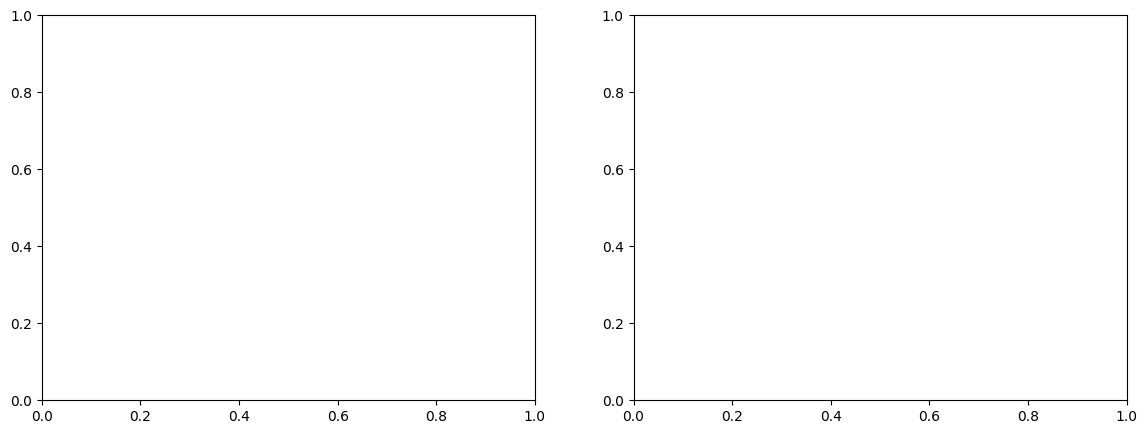

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before refinement
if len(error_values_before) > 0:
    axes[0].hist(error_values_before, bins=50, color='red', alpha=0.7, edgecolor='black')
    axes[0].axvline(x=3, color='green', linestyle='--', linewidth=2, label='3px threshold')
    axes[0].axvline(x=mean_error_before, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_error_before:.2f}px')
    axes[0].legend()
axes[0].set_xlabel('Reprojection Error (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'BEFORE Refinement ({len(points_before)} points)')

# After refinement
if len(error_values_after) > 0 and error_values_after != [0]:
    axes[1].hist(error_values_after, bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='3px threshold')
    axes[1].axvline(x=mean_error_after, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_error_after:.2f}px')
    axes[1].legend()
axes[1].set_xlabel('Reprojection Error (pixels)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'AFTER Refinement ({len(sfm.points_3d)} points)')

plt.suptitle('Reprojection Error Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('reprojection_error_histogram.png', dpi=150)
plt.show()

In [13]:
camera_centers = sfm.get_camera_centers()

fig = plt.figure(figsize=(14, 6))

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')
if len(sfm.points_3d) > 0:
    colors_normalized = sfm.point_colors/255.0 if len(sfm.point_colors) > 0 else 'gray'
    ax1.scatter(sfm.points_3d[:, 0], sfm.points_3d[:, 1], sfm.points_3d[:, 2], 
                c=colors_normalized, s=1, alpha=0.5)
ax1.scatter(camera_centers[:, 0], camera_centers[:, 1], camera_centers[:, 2], 
            c='red', s=100, marker='^', label='Cameras')
ax1.plot(camera_centers[:, 0], camera_centers[:, 1], camera_centers[:, 2], 
         'r-', linewidth=2, alpha=0.7)

for i, center in enumerate(camera_centers):
    ax1.text(center[0], center[1], center[2], f'{i}', fontsize=8)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Reconstruction with Camera Trajectory')
ax1.legend()

# Top-down view (X-Z plane)
ax2 = fig.add_subplot(122)
if len(sfm.points_3d) > 0:
    ax2.scatter(sfm.points_3d[:, 0], sfm.points_3d[:, 2], c='gray', s=1, alpha=0.3)
ax2.scatter(camera_centers[:, 0], camera_centers[:, 2], c='red', s=100, marker='^')
ax2.plot(camera_centers[:, 0], camera_centers[:, 2], 'r-', linewidth=2)

for i, center in enumerate(camera_centers):
    ax2.annotate(f'{i}', (center[0], center[2]), fontsize=8)

ax2.set_xlabel('X')
ax2.set_ylabel('Z (depth)')
ax2.set_title('Camera Trajectory (Top-Down View)')
ax2.axis('equal')

plt.tight_layout()
plt.savefig('camera_trajectory.png', dpi=150)
plt.show()

# Camera trajectory analysis
print("\nCamera Trajectory Analysis:")
print(f"Number of cameras: {len(camera_centers)}")
if len(camera_centers) > 1:
    inter_camera_distances = np.linalg.norm(np.diff(camera_centers, axis=0), axis=1)
    print(f"Total path length: {np.sum(inter_camera_distances):.2f} units")
    print(f"Mean inter-camera distance: {np.mean(inter_camera_distances):.2f}")
    print(f"Max inter-camera distance: {np.max(inter_camera_distances):.2f}")
    if np.max(inter_camera_distances) > 3 * np.mean(inter_camera_distances):
        print("⚠️ WARNING: Large jump detected in camera trajectory!")
    else:
        print("✓ Camera trajectory appears smooth")

NameError: name 'sfm' is not defined

NameError: name 'points_before' is not defined

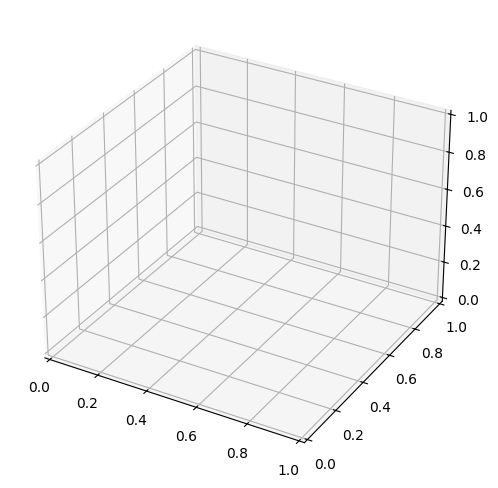

In [14]:
fig = plt.figure(figsize=(14, 6))

# Before refinement
ax1 = fig.add_subplot(121, projection='3d')
if len(points_before) > 0:
    colors_before_norm = colors_before/255.0 if len(colors_before) > 0 else 'blue'
    ax1.scatter(points_before[:, 0], points_before[:, 1], points_before[:, 2], 
                c=colors_before_norm, s=1, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'BEFORE Refinement\n({len(points_before)} points)')

# After refinement
ax2 = fig.add_subplot(122, projection='3d')
if len(sfm.points_3d) > 0:
    colors_after_norm = sfm.point_colors/255.0 if len(sfm.point_colors) > 0 else 'green'
    ax2.scatter(sfm.points_3d[:, 0], sfm.points_3d[:, 1], sfm.points_3d[:, 2], 
                c=colors_after_norm, s=1, alpha=0.6)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title(f'AFTER Refinement\n({len(sfm.points_3d)} points)')

plt.tight_layout()
plt.savefig('point_cloud_comparison.png', dpi=150)
plt.show()

ValueError: max() iterable argument is empty

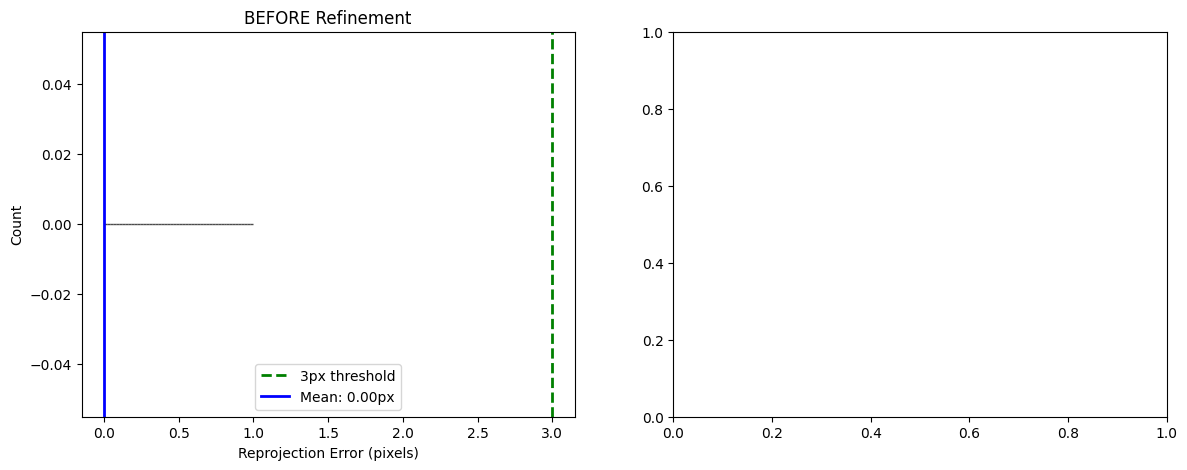

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before refinement
axes[0].hist(error_values_before, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].axvline(x=3, color='green', linestyle='--', linewidth=2, label='3px threshold')
axes[0].axvline(x=mean_error_before, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_error_before:.2f}px')
axes[0].set_xlabel('Reprojection Error (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('BEFORE Refinement')
axes[0].legend()
axes[0].set_xlim(0, min(20, max(error_values_before) + 1))

# After refinement
if len(error_values_after) > 0:
    axes[1].hist(error_values_after, bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='3px threshold')
    axes[1].axvline(x=mean_error_after, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_error_after:.2f}px')
    axes[1].set_xlim(0, min(20, max(error_values_after) + 1))
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Reprojection Error (pixels)')
axes[1].set_ylabel('Count')
axes[1].set_title('AFTER Refinement')
axes[1].legend()

plt.suptitle('Reprojection Error Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('reprojection_error_histogram.png', dpi=150)
plt.show()

In [15]:
sfm.save_ply("reconstruction_refined.ply")

# Save camera poses
sfm.save_cameras("camera_poses.json")

# Save statistics
stats = {
    'total_images': len(images),
    'registered_cameras': len(sfm.camera_poses),
    'failed_views': failed_views,
    'points_before_refinement': int(len(points_before)),
    'points_after_refinement': int(len(sfm.points_3d)),
    'mean_error_before': float(mean_error_before),
    'mean_error_after': float(mean_error_after),
    'camera_centers': camera_centers.tolist()
}

with open('reconstruction_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

NameError: name 'sfm' is not defined